# 04 – Segment-Features & Silhouette (Vorbereitung Clustering)

Berechnet pro Site die Tageszeit-Segment-Features (`features/segments.py`), persistiert
sie und untersucht via Silhouette/Elbow, welche Clusterzahl `k` je Clustering plausibel
ist. **Fit/Silhouette nur auf dem Train-Slice (2023–2024)** – das Parquet enthält alle
Jahre, aber k-Wahl und Cluster-Zentren werden ohne Test-Leakage bestimmt.

In [1]:
from __future__ import annotations

import sys
from pathlib import Path

import numpy as np
import pandas as pd
import yaml
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from rausch_energy_anomaly.ingestion import rlm_loader as loader  # noqa: E402
from rausch_energy_anomaly.features.segments import compute_segment_features  # noqa: E402

FIG = ROOT / "reports" / "figures"
FIG.mkdir(parents=True, exist_ok=True)
PROCESSED = ROOT / "data" / "processed"

cfg = yaml.safe_load((ROOT / "config" / "config.yaml").read_text(encoding="utf-8"))
SEGMENTS = cfg["clustering"]["segmente"]["segments"]
FEATURES = cfg["clustering"]["segmente"]["features_per_segment"]
K_SEG = cfg["clustering"]["segmente"]["k_values"]
K_DAILY = cfg["clustering"]["tagesprofile"]["k_values"]
SEG_NAMES = [s["name"] for s in SEGMENTS]
TRAIN_END = pd.to_datetime("2024-12-31").date()   # Train-Slice: 2023–2024
SEED = cfg["general"]["seed"]

plt.rcParams.update({"figure.dpi": 110, "figure.figsize": (11, 4), "axes.grid": True, "grid.alpha": 0.3})


def savefig(fig, name: str) -> None:
    fig.tight_layout()
    fig.savefig(FIG / name, dpi=150, bbox_inches="tight")
    print("gespeichert:", FIG.name + "/" + name)

## 1. Segment-Features pro Site berechnen
Baumärkte laden, flache Zähler (vmax < 1 kW) ausschließen, je Site die Segment-Features.

In [2]:
df = loader.load_category("Baumärkte")
vmax = df.groupby(level="meter_id")["value_kw"].max()
solid_ids = sorted(vmax[vmax >= 1.0].index)
print("Solide Zähler:", len(solid_ids))

parts = []
for sid in solid_ids:
    sdf = df.xs(sid, level="meter_id")
    feat = compute_segment_features(sdf, sid, SEGMENTS, FEATURES)
    feat["site"] = sid
    parts.append(feat.set_index("site", append=True).reorder_levels(["site", "date"]))
seg = pd.concat(parts).sort_index()
seg.to_parquet(PROCESSED / "segment_features.parquet")
print("segment_features:", seg.shape)
seg.head(3)

site=Baumarkt_03: 4 Segment-Tag(e) mit <80% erwarteter Punkte (incomplete=True)


site=Baumarkt_05: 4 Segment-Tag(e) mit <80% erwarteter Punkte (incomplete=True)


site=Baumarkt_06: 4 Segment-Tag(e) mit <80% erwarteter Punkte (incomplete=True)


site=Baumarkt_07: 4 Segment-Tag(e) mit <80% erwarteter Punkte (incomplete=True)


site=Baumarkt_08: 4 Segment-Tag(e) mit <80% erwarteter Punkte (incomplete=True)


...

site=Baumarkt_24: 4 Segment-Tag(e) mit <80% erwarteter Punkte (incomplete=True)


site=Baumarkt_25: 4 Segment-Tag(e) mit <80% erwarteter Punkte (incomplete=True)


site=Baumarkt_26: 4 Segment-Tag(e) mit <80% erwarteter Punkte (incomplete=True)


segment_features: (23242, 20)


nachts_mean  nachts_max  nachts_std  nachts_slope  \
site        date                                                            
Baumarkt_03 2023-01-01    11.000000        13.8    1.419347     -0.006324   
            2023-01-02    11.133333        13.4    1.386477      0.100870   
            2023-01-03    12.491667        15.0    1.453008      0.092174   

                        nachts_incomplete  vormittag_mean  vormittag_max  \
site        date                                                           
Baumarkt_03 2023-01-01              False           10.36           13.6   
            2023-01-02              False           52.17           78.4   
            2023-01-03              False           58.93           90.4   

                        vormittag_std  vormittag_slope  vormittag_incomplete  \
site        date                                                               
Baumarkt_03 2023-01-01       1.518448        -0.718195                 False   
            2023-01-02      28.080282        16.215940                 False   
            2023-01-03      29.546557        16.516692                 False   

                        mittag_mean  mittag_max  mittag_std  mittag_slope  \
site        date                                                            
Baumarkt_03 2023-01-01     8.000000         9.0    0.676891     -0.587413   
            2023-01-02    75.666667        77.6    1.687027      0.945455   
            2023-01-03    76.783333        80.2    2.125958     -1.658741   

                        mittag_incomplete  nachmittag_mean  nachmittag_max  \
site        date                                                             
Baumarkt_03 2023-01-01              False         10.34375            13.6   
            2023-01-02              False         63.86875            91.4   
            2023-01-03              False         62.24375            98.2   

                        nachmittag_std  nachmittag_slope  \
site        date                                           
Baumarkt_03 2023-01-01        1.895485          0.532111   
            2023-01-02       30.163110         -9.183431   
            2023-01-03       33.810391         -9.724780   

                        nachmittag_incomplete  
site        date                               
Baumarkt_03 2023-01-01                  False  
            2023-01-02                  False  
            2023-01-03                  False

## 2. Train-Slice (2023–2024) und Vollständigkeits-Maske

`fit`/Silhouette nutzen **nur** Tage bis `TRAIN_END` und schließen je Segment die
`*_incomplete`-Tage aus. Das Parquet bleibt vollständig (alle Jahre, inkl. incomplete).

In [3]:
dates = seg.index.get_level_values("date")
train_mask = pd.Series([d <= TRAIN_END for d in dates], index=seg.index)
print("Zeilen gesamt:", len(seg), "| im Train-Slice:", int(train_mask.sum()))
inc_rate = {s: float(seg[f"{s}_incomplete"].mean()) for s in SEG_NAMES}
print("Incomplete-Rate je Segment:", {k: round(v, 4) for k, v in inc_rate.items()})

Zeilen gesamt: 23242 | im Train-Slice: 14703
Incomplete-Rate je Segment: {'nachts': 0.001, 'vormittag': 0.001, 'mittag': 0.001, 'nachmittag': 0.001}


## 3. Visualisierung

/var/folders/6x/0jtnv68j031_8bd1s9hjbnrw0000gn/T/ipykernel_94666/477481205.py:4: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=SEG_NAMES, showfliers=False)


gespeichert: figures/04_segment_mean_verteilung.png


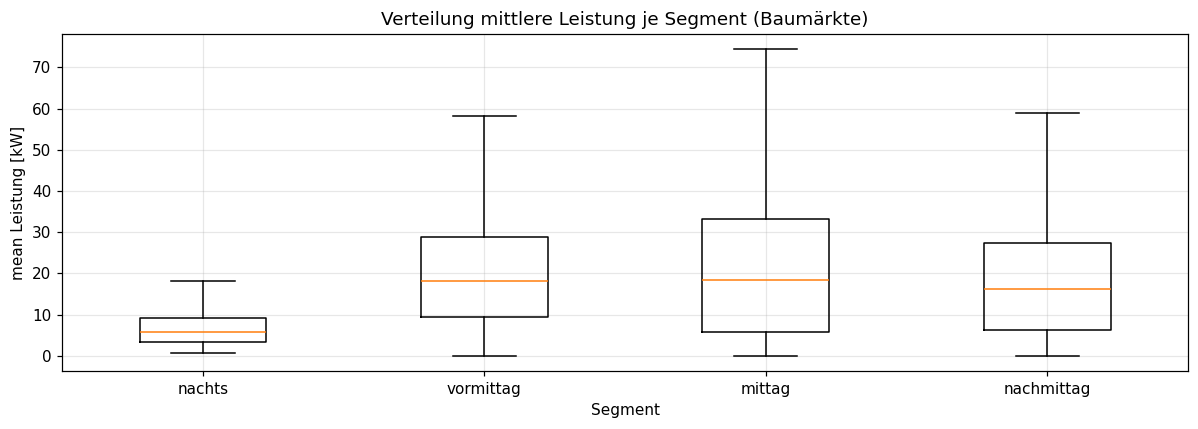

In [4]:
# Verteilung des mean je Segment (Form/Größe der Tageszeiten)
fig, ax = plt.subplots()
data = [seg[f"{s}_mean"].dropna().values for s in SEG_NAMES]
ax.boxplot(data, labels=SEG_NAMES, showfliers=False)
ax.set_title("Verteilung mittlere Leistung je Segment (Baumärkte)")
ax.set_xlabel("Segment")
ax.set_ylabel("mean Leistung [kW]")
savefig(fig, "04_segment_mean_verteilung.png")
plt.show()

gespeichert: figures/04_incomplete_ueber_zeit.png


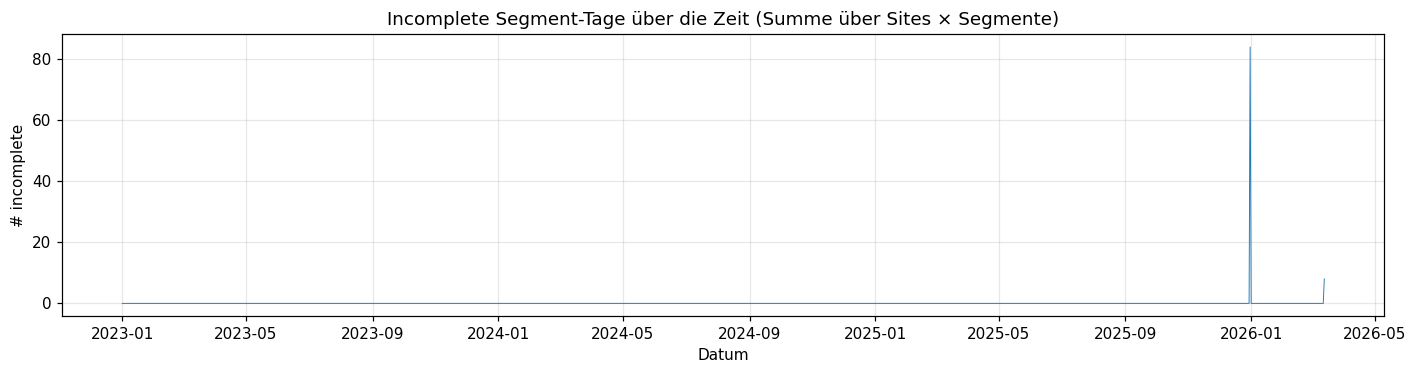

In [5]:
# Incomplete-Rate über die Zeit (DST-/Ausfalltage sichtbar) – Summe je Tag über Segmente
inc_cols = [f"{s}_incomplete" for s in SEG_NAMES]
by_day = seg[inc_cols].groupby(level="date").sum().sum(axis=1)
fig, ax = plt.subplots(figsize=(13, 3.5))
ax.plot(list(by_day.index), by_day.values, lw=0.6)
ax.set_title("Incomplete Segment-Tage über die Zeit (Summe über Sites × Segmente)")
ax.set_xlabel("Datum")
ax.set_ylabel("# incomplete")
savefig(fig, "04_incomplete_ueber_zeit.png")
plt.show()

## 4. Silhouette + Elbow zur k-Wahl

- **Tagesprofile** (96-dim): pro Zeile (site, day) normiert (Form) → ein Clustering.
- **Pro Segment**: 4 Features (mean/max/std/slope), **pro Segment getrennt standardisiert**
  (sonst clustert man Tag vs. Nacht statt Form innerhalb der Tageszeit). Vier Clusterings.

`silhouette_score` mit `sample_size` (O(n²)-Schutz).

In [6]:
def elbow_silhouette(X: np.ndarray, ks: list[int], title: str, fname: str) -> int:
    inertia, sil = [], []
    for k in ks:
        km = KMeans(n_clusters=k, n_init=10, random_state=SEED).fit(X)
        inertia.append(km.inertia_)
        ssize = min(2000, len(X))
        sil.append(silhouette_score(X, km.labels_, sample_size=ssize, random_state=SEED))
    fig, (a1, a2) = plt.subplots(1, 2, figsize=(11, 3.6))
    a1.plot(ks, inertia, marker="o"); a1.set_title(f"Elbow – {title}"); a1.set_xlabel("k"); a1.set_ylabel("Inertia")
    a2.plot(ks, sil, marker="o", color="tab:green"); a2.set_title(f"Silhouette – {title}"); a2.set_xlabel("k"); a2.set_ylabel("Silhouette")
    savefig(fig, fname)
    plt.show()
    best = int(ks[int(np.argmax(sil))])
    print(f"{title}: bestes k (Silhouette) = {best}")
    return best

gespeichert: figures/04_silhouette_tagesprofile.png


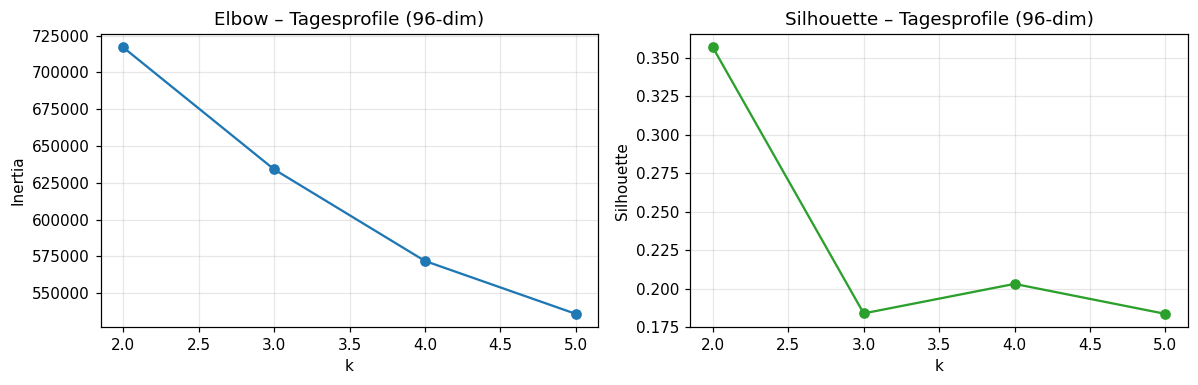

Tagesprofile (96-dim): bestes k (Silhouette) = 2


In [7]:
# (a) Tagesprofile 96-dim, Train-Slice, zeilenweise normiert
ts = df.loc[solid_ids].index.get_level_values("timestamp")
tmp = pd.DataFrame({
    "site": df.loc[solid_ids].index.get_level_values("meter_id"),
    "date": ts.date,
    "slot": ts.hour * 4 + ts.minute // 15,
    "value": df.loc[solid_ids]["value_kw"].values,
})
daily = tmp.pivot_table(index=["site", "date"], columns="slot", values="value").dropna(thresh=90)
daily = daily[[d <= TRAIN_END for d in daily.index.get_level_values("date")]]
row_mean = daily.mean(axis=1)
daily = daily.apply(lambda col: col.fillna(row_mean))   # Rest-NaN je Zeile mit Zeilenmittel
Xd = daily.to_numpy()
Xd = (Xd - Xd.mean(1, keepdims=True)) / (Xd.std(1, keepdims=True) + 1e-9)
best_daily = elbow_silhouette(Xd, K_DAILY, "Tagesprofile (96-dim)", "04_silhouette_tagesprofile.png")

gespeichert: figures/04_silhouette_segment_nachts.png


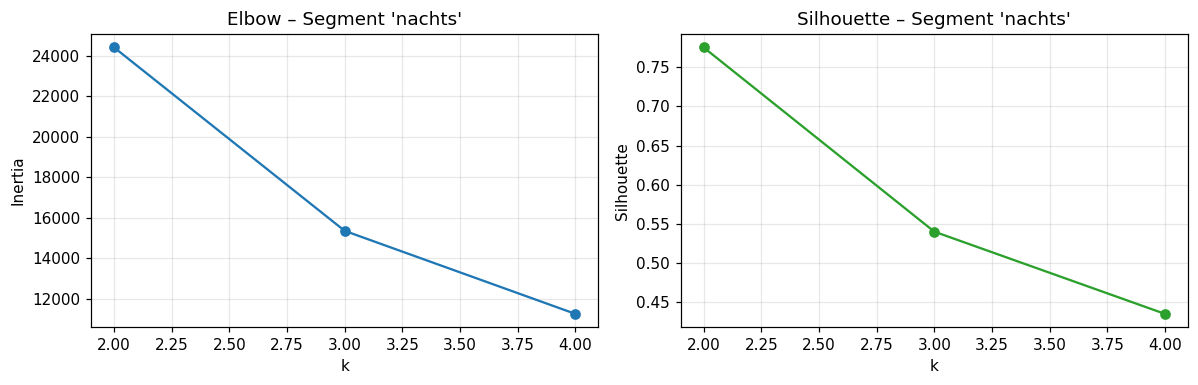

Segment 'nachts': bestes k (Silhouette) = 2


gespeichert: figures/04_silhouette_segment_vormittag.png


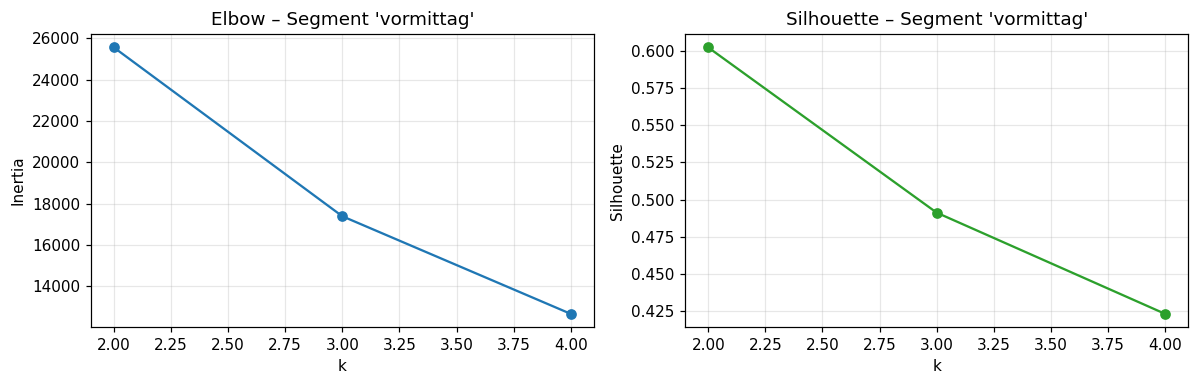

Segment 'vormittag': bestes k (Silhouette) = 2


gespeichert: figures/04_silhouette_segment_mittag.png


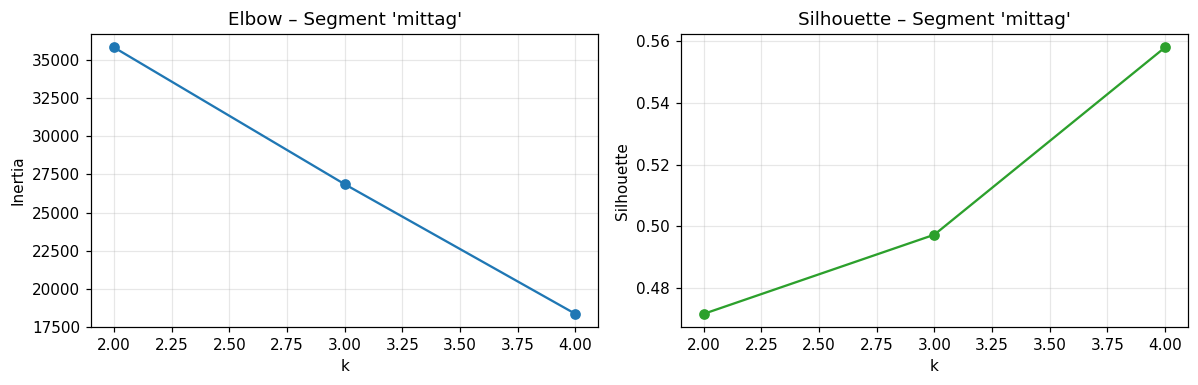

Segment 'mittag': bestes k (Silhouette) = 4


gespeichert: figures/04_silhouette_segment_nachmittag.png


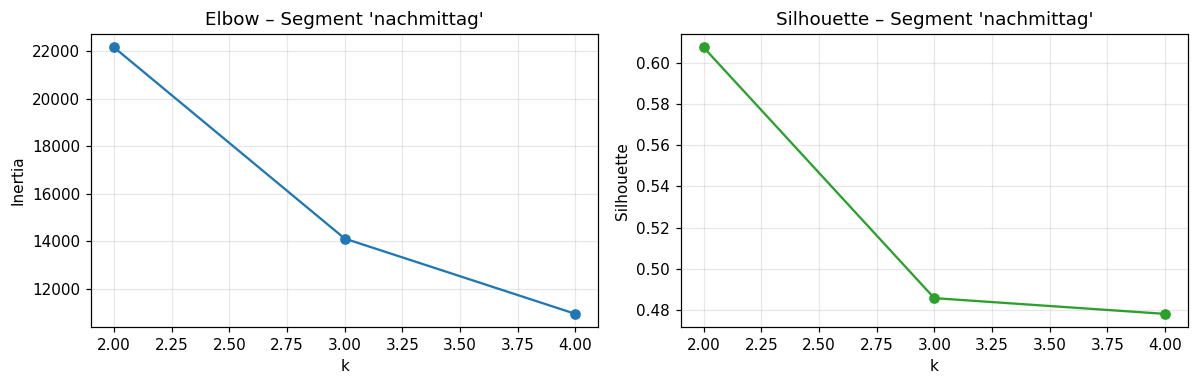

Segment 'nachmittag': bestes k (Silhouette) = 2
Beste k je Clustering: {'tagesprofile': 2, 'nachts': 2, 'vormittag': 2, 'mittag': 4, 'nachmittag': 2}


In [8]:
# (b) Pro Segment: 4 Features, Train-Slice, incomplete raus, PRO SEGMENT standardisiert
best_seg = {}
for s in SEG_NAMES:
    cols = [f"{s}_{f}" for f in FEATURES]
    mask = train_mask & ~seg[f"{s}_incomplete"].astype(bool)
    sub = seg.loc[mask, cols].dropna()
    Xs = StandardScaler().fit_transform(sub.to_numpy())
    best_seg[s] = elbow_silhouette(Xs, K_SEG, f"Segment '{s}'", f"04_silhouette_segment_{s}.png")
print("Beste k je Clustering:", {"tagesprofile": best_daily, **best_seg})

## 5. Befunde & wie die fünf Clusterings zusammengeführt werden

**Ergebnisse (Train-Slice 2023–2024, 23 solide Baumärkte, 23.242 Segment-Tage gesamt, davon 14.703 im Train):**
- **Silhouette-bevorzugtes k:** Tagesprofil **2**, nachts **2**, vormittag **2**, mittag **4**, nachmittag **2**.
- Silhouette favorisiert also überwiegend eine **grobe Zwei-Cluster-Trennung** (typisch vs. atypisch); nur das **Mittag**-Segment zeigt feinere Struktur (k=4). Die finale k-Wahl trifft Schritt 6 (ggf. mit fachlicher statt rein silhouette-getriebener Begründung, da k=2 sehr grob ist).
- **Incomplete-Rate ≈ 0,1 %** je Segment → bei den (sauberen) ZRV-Baumärkten verändert der Incomplete-Ausschluss den Fit kaum; die Mechanik ist v. a. für DST-/Ausfalltage und die kWh-Lastgang-Sites relevant.

**Entscheidungen (dokumentiert):**
- **Fit nur auf Train-Slice 2023–2024**, k-Wahl/Zentren ohne Test-Leakage; das Parquet
  `segment_features.parquet` enthält alle Jahre (inkl. 2025–2026) für die spätere Diagnose.
- **Incomplete Segment-Tage** (`*_incomplete = True`, v. a. DST-/Ausfalltage) sind aus dem
  Fit ausgeschlossen, bleiben aber im Parquet erhalten.
- **Pro-Segment-Standardisierung** (getrennt je Segment), damit die Cluster Form-Unterschiede
  *innerhalb* einer Tageszeit abbilden, nicht den trivialen Tag-vs-Nacht-Niveauunterschied.

**Fünf Clusterings nebeneinander – geplante Zusammenführung (Schritt 6 / `diagnosis`):**
- Es entstehen **fünf** Cluster-Modelle: 1× Tagesprofil (96-dim) + 4× Segment.
- Pro (site, day) liefert jedes Modell **ein Cluster-Label** → fünf Labels je Tag.
- Das **Tagesprofil-Label** beschreibt den *Gesamtcharakter* des Tages (welcher Typ-Tag),
  die **vier Segment-Labels** lokalisieren, *welche Tageszeit* abweicht.
- In `diagnosis/anomaly_classifier.py` werden die Labels **nicht** zu einem Modell verschmolzen,
  sondern als Kontext kombiniert: Anomalie-Score (aus ARIMA/AE) + das auffällige
  Segment-Label → Aussage „Nachmittag, Cluster 3 = ungewöhnlich hoch". Das Tagesprofil-Label
  dient als Quervalidierung (untypischer Tag insgesamt?). So bleiben die Clusterings verbunden
  statt fünf isolierter Ergebnisse.